In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

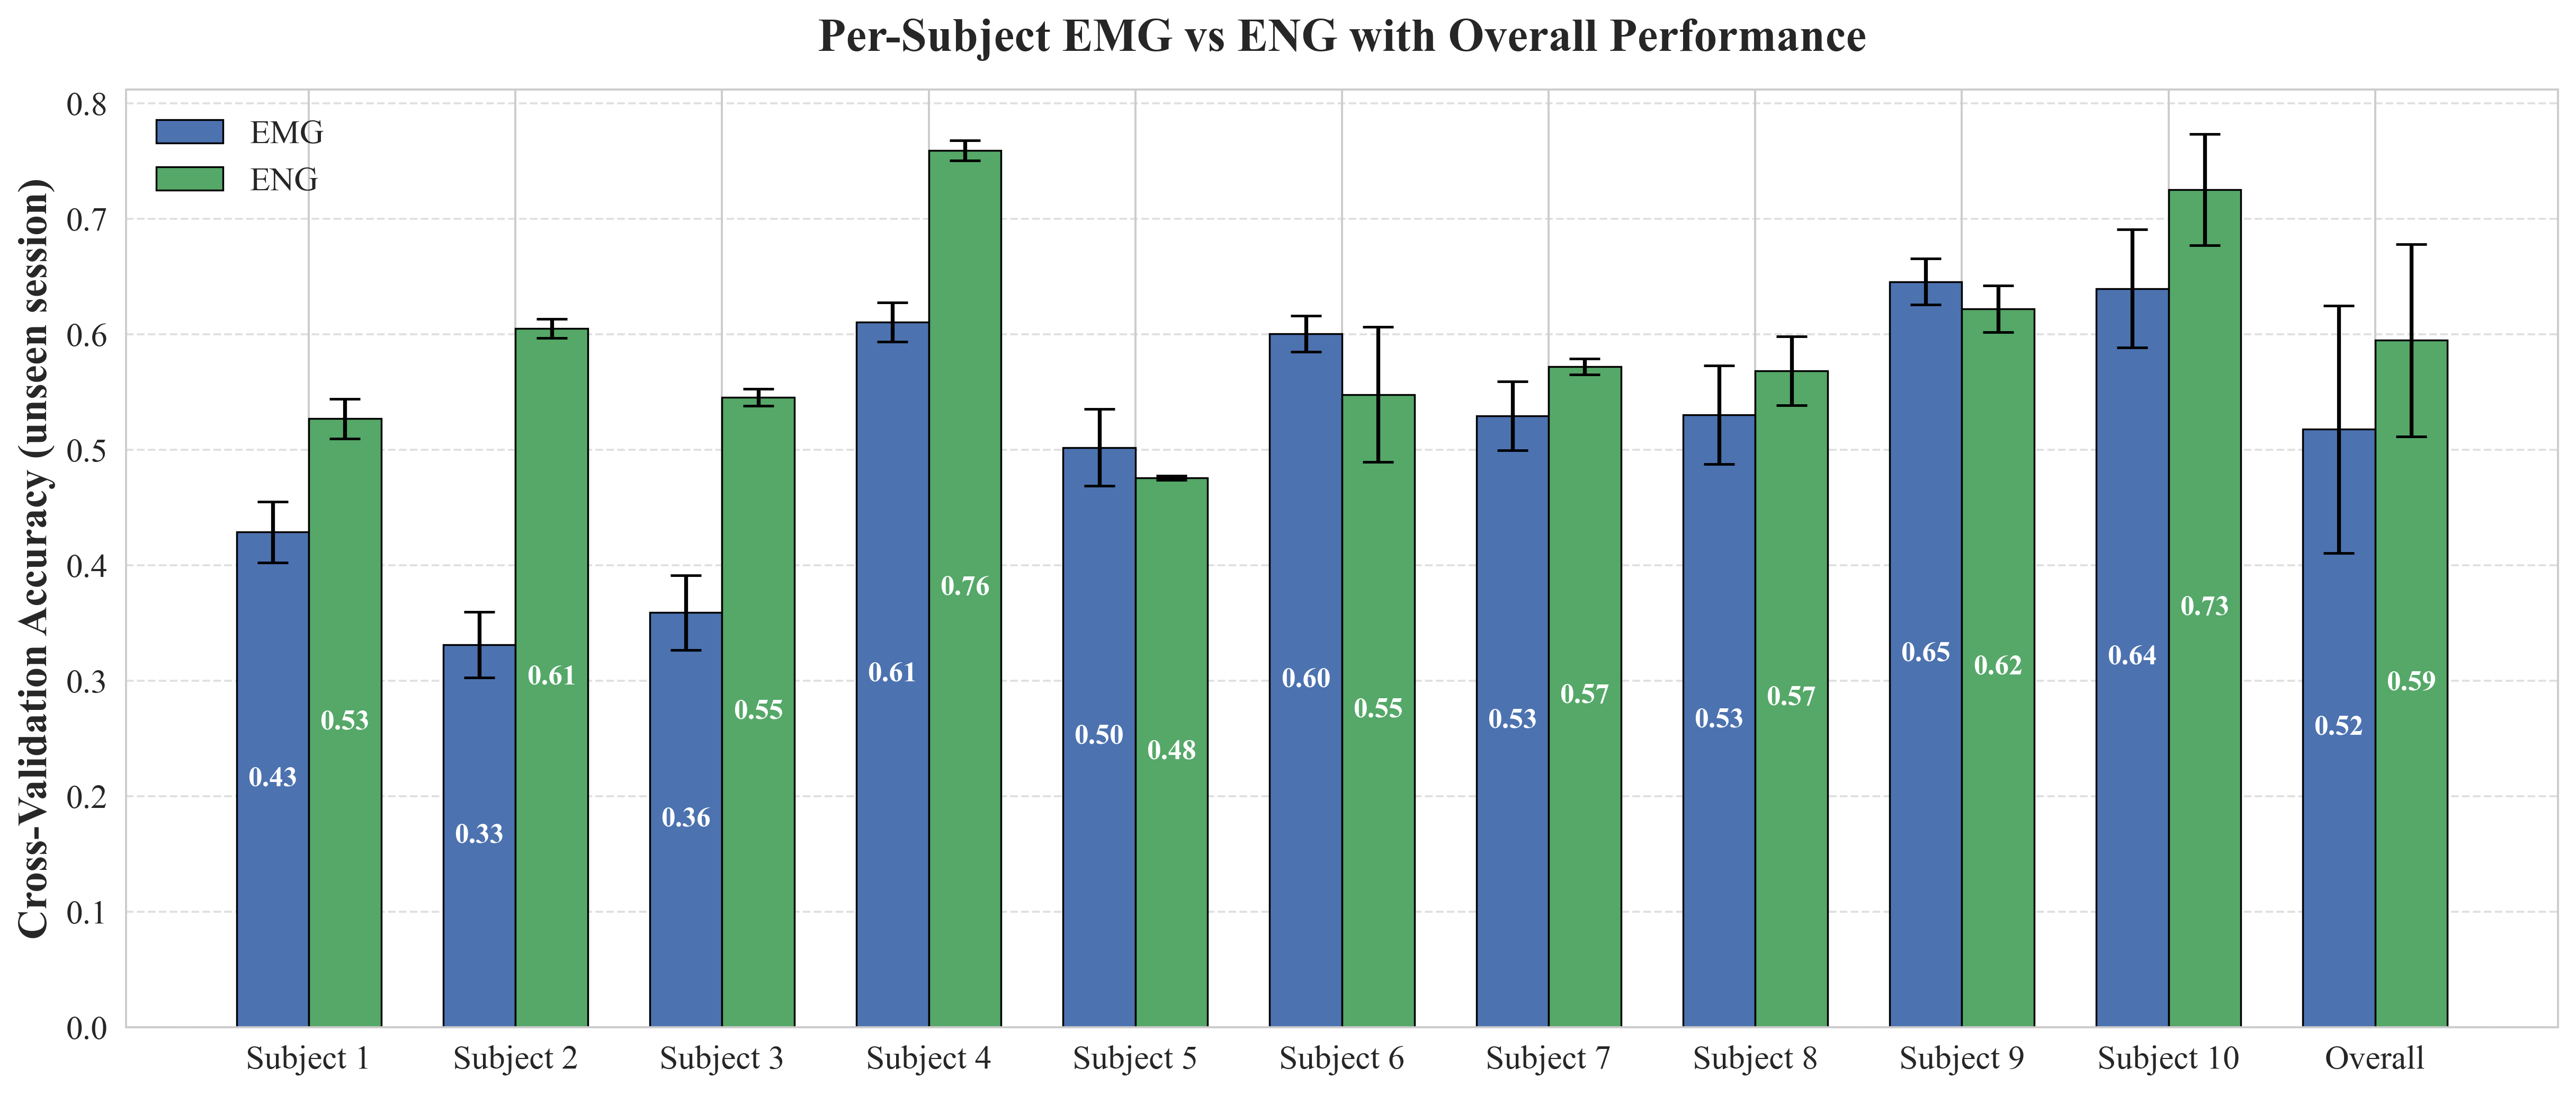

In [33]:
plt.rcParams['font.family'] = 'Times New Roman'
ENG_result_mean = [0.5268587470054626, 0.6050552427768707, 0.545380711555481, 0.7593218088150024, 0.4755933475494385, 0.5478944170475006, 0.5720518922805786, 0.5684217519760132, 0.6220743030309677, 0.7251902371163402]

EMG_result_mean = [0.42878782749176025, 0.3310706913471222, 0.35904206335544586, 0.6106011271476746, 0.5019441395998001, 0.6005978584289551,
                   0.5293917655944824, 0.5303820222616196, 0.6454729735851288, 0.639594031062847]

ENG_result_std = [0.01738905906677246, 0.008295983076095581, 0.007301270961761475, 0.008739054203033447, 0.001889646053314209, 0.05837675929069519,
                  0.006995737552642822, 0.029935557842254639, 0.02, 0.0481075885192015]

EMG_result_std = [0.026361674070358276, 0.028349608182907104, 0.032305046916007996, 0.01692497730255127, 0.033312246203422546, 0.01564866304397583,
                  0.02972644567489624, 0.04258860647678375, 0.02, 0.05109803514926083]

# Subjects
subjects = [f"Subject {i+1}" for i in range(len(["HM", "BY", "HJ", "JI", "YC", "HR", "CS", "MJ", "XY", "BR"]))]

# ---- Overall mean & std ----
EMG_overall_mean = np.mean(EMG_result_mean)
ENG_overall_mean = np.mean(ENG_result_mean)
EMG_overall_std = np.std(EMG_result_mean)
ENG_overall_std = np.std(ENG_result_mean)

# Append to list
subjects_with_overall = subjects + ["Overall"]
EMG_result_mean.append(EMG_overall_mean)
ENG_result_mean.append(ENG_overall_mean)
EMG_result_std.append(EMG_overall_std)
ENG_result_std.append(ENG_overall_std)

# ---- Barplot ----
x = np.arange(len(subjects_with_overall))  # subject index
width = 0.35

fig, ax = plt.subplots(figsize=(14,6), dpi=350)

bars1 = ax.bar(x - width/2, EMG_result_mean, width,
               yerr=EMG_result_std, capsize=6, label="EMG",
               color="#4C72B0", edgecolor="black", linewidth=0.7)
bars2 = ax.bar(x + width/2, ENG_result_mean, width,
               yerr=ENG_result_std, capsize=6, label="ENG",
               color="#55A868", edgecolor="black", linewidth=0.7)

# Labels & Title
ax.set_ylabel("Cross-Validation Accuracy (unseen session)", fontsize=16, weight="bold")
ax.set_title("Per-Subject EMG vs ENG with Overall Performance", fontsize=18, weight="bold", pad=15)
ax.set_xticks(x)
ax.set_xticklabels(subjects_with_overall, fontsize=13, rotation=0)
ax.tick_params(axis="y", labelsize=13)

# Grid for readability
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

# Legend
ax.legend(fontsize=13, frameon=False)

'''
# Annotate bars with values (shift higher to avoid overlap with error bars)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0,8), textcoords="offset points",   # ⬅︎ 여기 offset을 늘림
                    ha='center', va='bottom',
                    fontsize=11, weight="bold")
'''


# Annotate bars with values (inside bars)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height/2),  # 막대 중간쯤에 표시
                    ha='center', va='center',
                    fontsize=11, weight="bold", color="white")


plt.tight_layout()
plt.show()


In [25]:
len(EMG_result_mean), len(EMG_result_std),

(14, 14)